country_full                      key  \
0             1BA426_2HIM_F0G3N_V_MOO   
1             1BC167_RV44_F0038_V_B1M   
2             1BC229_2CYS_F04XV_V_LVM   
3             1BD394_RDLN_F0040_V_NOO   
4             1BG602_2HIK_F0036_V_OOO   
5             1BG644_2G6S_F0161_V_OOO   
6             1BZ039_RV44_F0002_V_DMM   
7             1BZ811_RV44_F0D57_V_OTM   
8                    1N204W_NZV_F0WHB   
9                   1N204X_R064_F0002   

country_full                                       product_name  US_total  \
0                   Prada Bonnie medium printed leather handbag    4158.0   
1                                         Re-Nylon shoulder bag    2322.0   
2                       Prada Aimée medium leather shoulder bag    3564.0   
3             Prada Explore medium Re-Nylon shoulder bag wit...    2700.0   
4                                        Large leather tote bag    5292.0   
5                 Prada Route large canvas and leather tote bag    3456.0   
6        

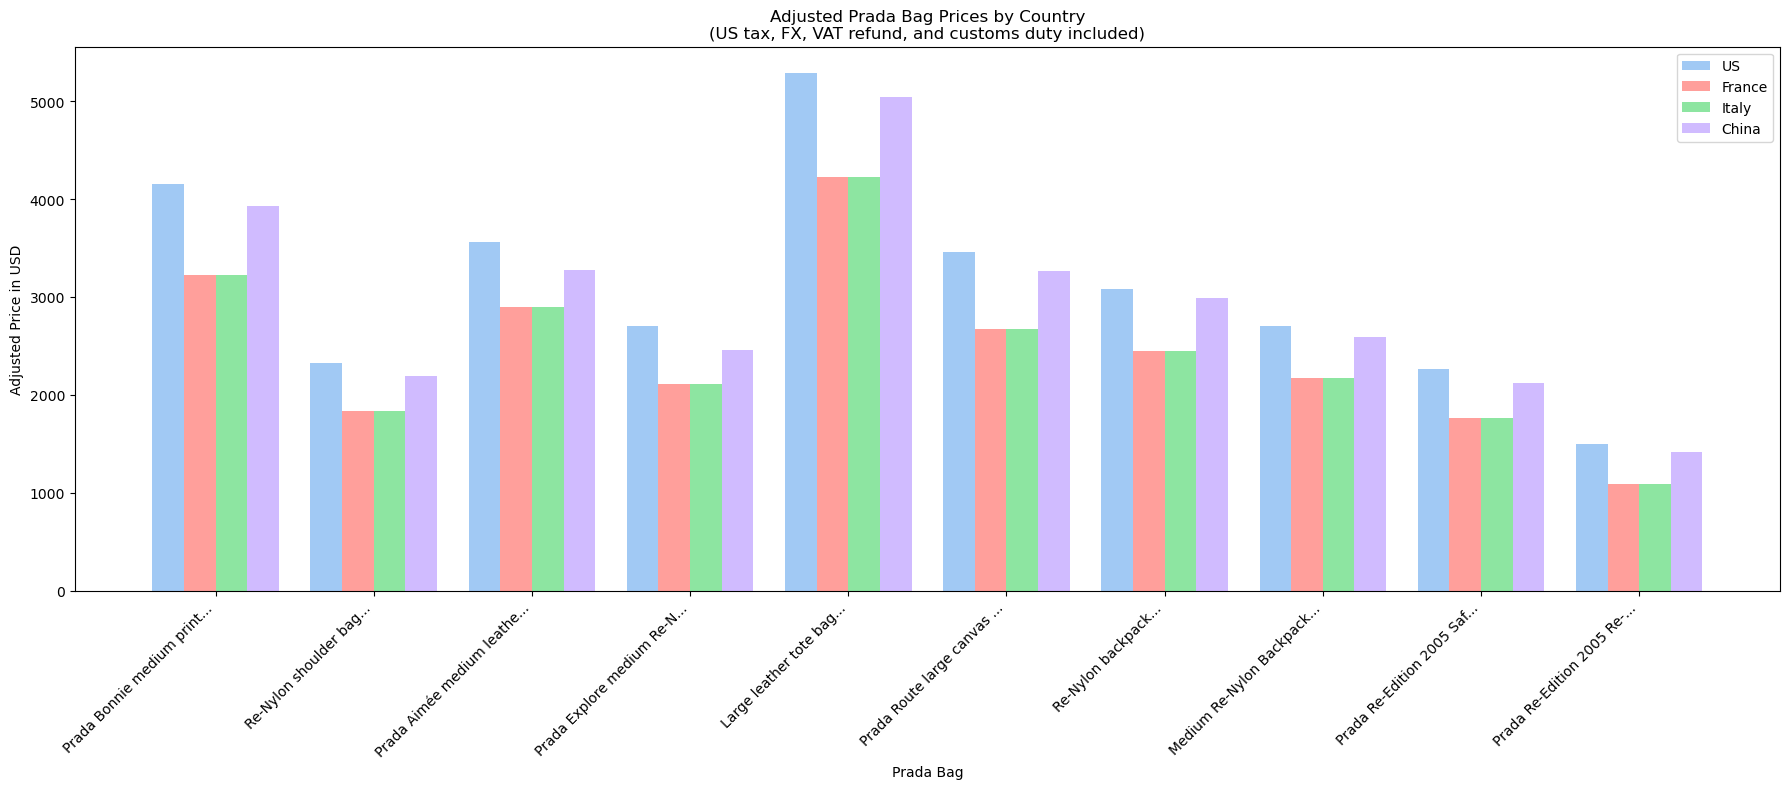

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA
# ----------------------------
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")
bags = pd.read_csv("prada_10bags_4countries_cleaned.csv", encoding="latin1")

# ----------------------------
# 2. CLEAN / STANDARDIZE
# ----------------------------
# Standardize country names across files
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

# Map country codes in bags file
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
bags["country_full"] = bags["country"].map(country_map)

# ----------------------------
# 3. PIVOT BAG PRICES TO WIDE FORMAT
# ----------------------------
wide = (
    bags.pivot_table(
        index=["key", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. SET SALES TAX FOR US
# ----------------------------
# Change this depending on what US tax rate you want to assume.
# Example: NY state only = 0.04
# Example: NYC = 0.08875
# Example: if you want an 8% assumption, use 0.08
us_sales_tax_rate = 0.08

# ----------------------------
# 5. BUILD LOOKUP DICTIONARIES
# ----------------------------
refund_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 6. CALCULATE ADJUSTED LANDED COSTS
# ----------------------------
# US adjusted price
wide["US_total"] = wide["US"] * (1 + us_sales_tax_rate)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert local price to USD
    wide[f"{c}_converted_usd"] = wide[c] * fx_lookup[c]

    # VAT refund amount in USD
    wide[f"{c}_vat_refund_usd"] = wide[f"{c}_converted_usd"] * refund_lookup[c]

    # Net foreign price after VAT refund
    wide[f"{c}_net_after_refund"] = (
        wide[f"{c}_converted_usd"] - wide[f"{c}_vat_refund_usd"]
    )

    # Customs duty in USD
    # Assumption: duty is applied to the post-refund imported value
    wide[f"{c}_custom_duty_usd"] = (
        wide[f"{c}_net_after_refund"] * duty_lookup[c]
    )

    # Final landed cost
    wide[f"{c}_total"] = (
        wide[f"{c}_net_after_refund"] + wide[f"{c}_custom_duty_usd"]
    )

    # Savings relative to buying in the US
    wide[f"{c}_savings_vs_US"] = wide["US_total"] - wide[f"{c}_total"]

# ----------------------------
# 7. OPTIONAL: VIEW RESULTS TABLE
# ----------------------------
result_cols = [
    "key", "product_name", "US_total",
    "France_total", "Italy_total", "China_total",
    "France_savings_vs_US", "Italy_savings_vs_US", "China_savings_vs_US"
]
print(wide[result_cols].round(2))

# ----------------------------
# 8. MAKE LABELS FOR X-AXIS
# ----------------------------
# You can use product_name, but they may be long.
# This creates shorter labels using the bag key.
wide["bag_label"] = wide["product_name"].str[:25] + "..."

# If you prefer exact bag codes instead, use:
# wide["bag_label"] = wide["key"]

# ----------------------------
# 9. GROUPED BAR CHART
# ----------------------------
plot_df = wide[["bag_label", "US_total", "France_total", "Italy_total", "China_total"]]

x = np.arange(len(plot_df))
bar_width = 0.2

plt.figure(figsize=(18, 8))

colors = {
    "US": "#a1c9f4",
    "France": "#ff9f9b",
    "Italy": "#8de5a1",
    "China": "#d0bbff"
}

plt.bar(x - 1.5 * bar_width, plot_df["US_total"], 
        width=bar_width, label="US", color=colors["US"])

plt.bar(x - 0.5 * bar_width, plot_df["France_total"], 
        width=bar_width, label="France", color=colors["France"])

plt.bar(x + 0.5 * bar_width, plot_df["Italy_total"], 
        width=bar_width, label="Italy", color=colors["Italy"])

plt.bar(x + 1.5 * bar_width, plot_df["China_total"], 
        width=bar_width, label="China", color=colors["China"])

plt.xticks(x, plot_df["bag_label"], rotation=45, ha="right")
plt.ylabel("Adjusted Price in USD")
plt.xlabel("Prada Bag")
plt.title("Adjusted Prada Bag Prices by Country\n(US tax, FX, VAT refund, and customs duty included)")
plt.legend()
plt.tight_layout()
plt.savefig("prada_barchart.png")
plt.show()

C:\Users\kayla\AppData\Local\Temp\ipykernel_12696\2999997563.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


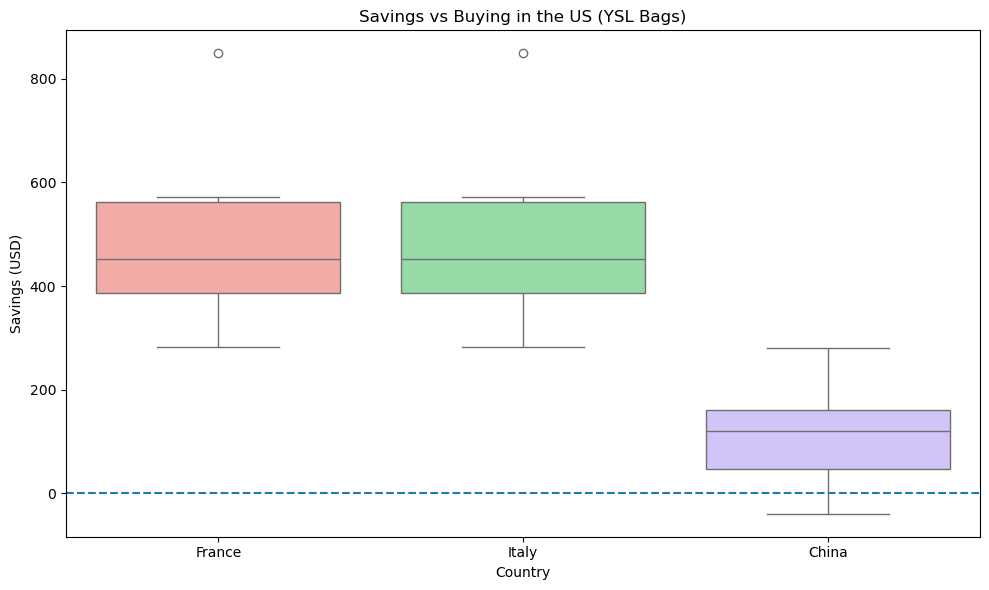

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. LOAD DATA
# ----------------------------
ysl = pd.read_csv("ysl_10bags_4countries_cleaned.csv")
vat = pd.read_csv("vat_rates_by_country.csv")
tariff = pd.read_csv("tariff_data.csv")
fx = pd.read_csv("Currency_Exchange_Rates.csv")

# ----------------------------
# 2. CLEAN + STANDARDIZE
# ----------------------------
vat["country"] = vat["Country"].str.strip()
vat = vat[["country", "Approx_Tax_Refund_Rate"]]

tariff["country"] = tariff["country"].str.strip()
tariff = tariff[["country", "Ad Valorem Rate"]]

fx["country"] = fx["country"].str.strip()
fx = fx[["country", "to_us"]]

# Map country codes
country_map = {
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
}
ysl.columns.tolist()
ysl["country_full"] = ysl["country"].map({
    "US": "US",
    "FR": "France",
    "IT": "Italy",
    "CN": "China"
})
ysl["country_full"] = ysl["country"].map(country_map)

# ----------------------------
# 3. PIVOT TO WIDE FORMAT
# ----------------------------
wide = (
    ysl.pivot_table(
        index=["sku", "product_name"],
        columns="country_full",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

# ----------------------------
# 4. LOOKUPS
# ----------------------------
vat_lookup = dict(zip(vat["country"], vat["Approx_Tax_Refund_Rate"]))
fx_lookup = dict(zip(fx["country"], fx["to_us"]))
duty_lookup = dict(zip(tariff["country"], tariff["Ad Valorem Rate"]))

# ----------------------------
# 5. PARAMETERS
# ----------------------------
us_tax = 0.08  # change if needed (NYC = 0.08875)

# ----------------------------
# 6. COMPUTE TOTALS
# ----------------------------
wide["US_total"] = wide["US"] * (1 + us_tax)

foreign_countries = ["France", "Italy", "China"]

for c in foreign_countries:
    # Convert to USD
    wide[f"{c}_usd"] = wide[c] * fx_lookup[c]
    
    # VAT refund
    wide[f"{c}_vat_refund"] = wide[f"{c}_usd"] * vat_lookup[c]
    
    # Net price after refund
    wide[f"{c}_net"] = wide[f"{c}_usd"] - wide[f"{c}_vat_refund"]
    
    # Customs duty (applied after refund)
    wide[f"{c}_duty"] = wide[f"{c}_net"] * duty_lookup[c]
    
    # Final landed cost
    wide[f"{c}_total"] = wide[f"{c}_net"] + wide[f"{c}_duty"]

# ----------------------------
# 7. COMPUTE SAVINGS VS US
# ----------------------------
wide["France_savings"] = wide["US_total"] - wide["France_total"]
wide["Italy_savings"] = wide["US_total"] - wide["Italy_total"]
wide["China_savings"] = wide["US_total"] - wide["China_total"]

# ----------------------------
# 8. RESHAPE FOR BOXPLOT
# ----------------------------
savings_df = wide.melt(
    id_vars=["product_name"],
    value_vars=["France_savings", "Italy_savings", "China_savings"],
    var_name="country",
    value_name="savings"
)

savings_df["country"] = savings_df["country"].str.replace("_savings", "")

# ----------------------------
# 9. BOXPLOT
# ----------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=savings_df,
    x="country",
    y="savings",
    palette={
        "France": colors["France"],
        "Italy": colors["Italy"],
        "China": colors["China"]
    }
)

plt.axhline(0, linestyle="--")  # break-even line

plt.title("Savings vs Buying in the US (YSL Bags)")
plt.ylabel("Savings (USD)")
plt.xlabel("Country")

plt.tight_layout()
plt.savefig("ysl_boxplot.png")
plt.show()